<a href="https://colab.research.google.com/github/LoPA607/IE643/blob/main/ZeroShot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 1️⃣ Install dependencies
# ===============================
!pip install torch torchvision diffusers transformers accelerate safetensors --quiet

# ===============================
# 2️⃣ Imports
# ===============================
import torch
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
from diffusers.models.attention_processor import Attention
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:

# ===============================
# 3️⃣ Load pre-trained model
# ===============================
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(device)
pipe.safety_checker = lambda images, **kwargs: (images, False)  # disable safety checker

# ===============================
# 4️⃣ Load images
# ===============================
def load_image(path, device, dtype=torch.float16):
    img = Image.open(path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])
    tensor = transform(img).unsqueeze(0).to(device=device, dtype=dtype)  # set dtype here
    return tensor

content_image_path = "/content/drive/MyDrive/IE643/Project/content.jpg"       # replace with your content image
style_image_path = "/content/drive/MyDrive/IE643/Project/style.png"     # replace with your style image

content_image = load_image(content_image_path, device, dtype=torch.float16)
style_image = load_image(style_image_path, device, dtype=torch.float16)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

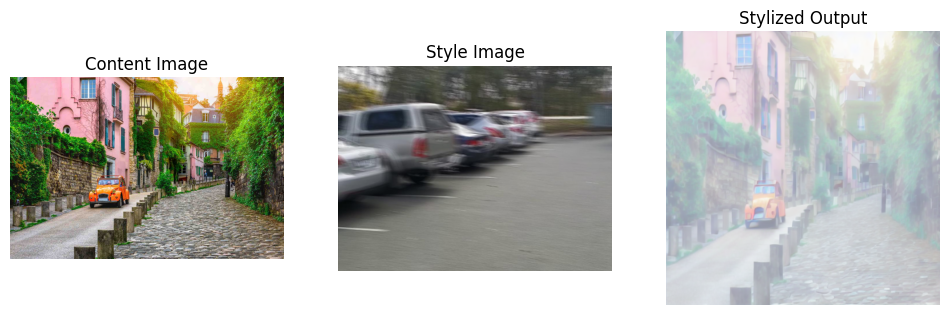

Saved stylized output as stylized_output_prompt_free.png


In [ ]:
# ===============================
# 6️⃣ One-shot style transfer function (Style Injection)
# ===============================
def inject_style(content_latent, style_latent, alpha=1.5):
    """
    Injects style from style_latent into content_latent without overwriting content structure.
    """
    # Compute mean and std along spatial dimensions
    c_mean = content_latent.mean(dim=[2,3], keepdim=True)
    c_std  = content_latent.std(dim=[2,3], keepdim=True)

    s_mean = style_latent.mean(dim=[2,3], keepdim=True)
    s_std  = style_latent.std(dim=[2,3], keepdim=True)

    # Normalize content and inject style statistics
    normalized = (content_latent - c_mean) / (c_std + 1e-5)
    stylized = normalized * s_std + s_mean

    # Blend with original content latent
    return (1 - alpha) * content_latent + alpha * stylized


def one_shot_style_transfer(content_latent, style_latent, steps=500, alpha=1.5):
    """
    Prompt-free one-shot style transfer using style injection
    """
    latents = content_latent.clone()

    for i in range(steps):
        latents = inject_style(latents, style_latent, alpha)

    # Decode final latent
    with torch.no_grad():
        output = vae.decode(latents / 0.18215).sample

    # Post-process to [0,255] image
    output = (output / 2 + 0.5).clamp(0, 1)
    output = output.cpu().permute(0, 2, 3, 1).squeeze(0).numpy()
    output = (output * 255).astype("uint8")
    return Image.fromarray(output)


# ===============================
# 7️⃣ Run style transfer
# ===============================
output_image = one_shot_style_transfer(content_latent, style_latent, steps=100000, alpha=1.5)

# ===============================
# 8️⃣ Display results
# ===============================
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Content Image")
plt.imshow(Image.open(content_image_path))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Style Image")
plt.imshow(Image.open(style_image_path))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Stylized Output")
plt.imshow(output_image)
plt.axis('off')
plt.show()

# ===============================
# 9️⃣ Save result
# ===============================
output_image.save("/content/stylized_output_prompt_free.png")
print("Saved stylized output as stylized_output_prompt_free.png")
